In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('cat.jpg')

# Split channels
b, g, r = cv2.split(img)

# Apply Sobel to each
sobel_b = cv2.Sobel(b, cv2.CV_64F, 1, 1, ksize=3)
sobel_g = cv2.Sobel(g, cv2.CV_64F, 1, 1, ksize=3)
sobel_r = cv2.Sobel(r, cv2.CV_64F, 1, 1, ksize=3)

# Merge
sobel_rgb = cv2.merge([
    cv2.convertScaleAbs(sobel_b),
    cv2.convertScaleAbs(sobel_g),
    cv2.convertScaleAbs(sobel_r)
])

cv2.imshow('Sobel on RGB', sobel_rgb)
cv2.waitKey(0)
cv2.destroyAllWindows()


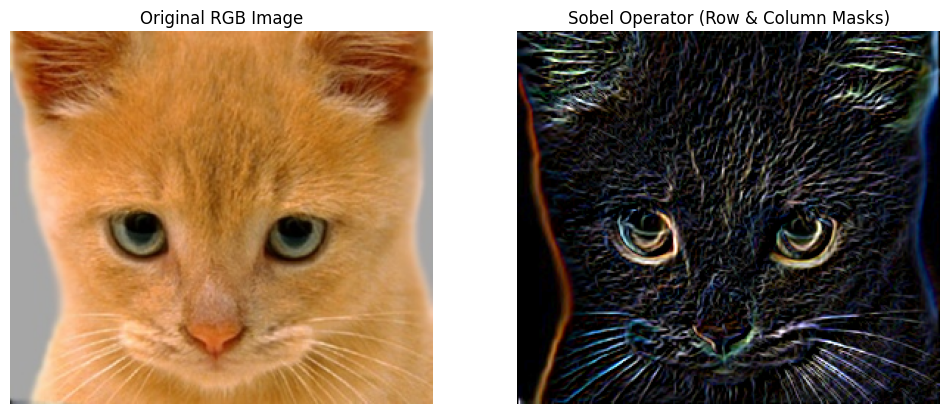

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load RGB image ---
img = cv2.imread('cat.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- Define Sobel masks manually ---
sobel_row = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]])

sobel_col = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]])

# --- Split RGB channels ---
r, g, b = cv2.split(img)

# --- Apply Sobel masks to each channel ---
r_row = cv2.filter2D(r, -1, sobel_row)
r_col = cv2.filter2D(r, -1, sobel_col)

g_row = cv2.filter2D(g, -1, sobel_row)
g_col = cv2.filter2D(g, -1, sobel_col)

b_row = cv2.filter2D(b, -1, sobel_row)
b_col = cv2.filter2D(b, -1, sobel_col)

# --- Combine results for each channel (magnitude) ---
r_edges = cv2.magnitude(np.float32(r_row), np.float32(r_col))
g_edges = cv2.magnitude(np.float32(g_row), np.float32(g_col))
b_edges = cv2.magnitude(np.float32(b_row), np.float32(b_col))

# --- Merge channels back to RGB ---
sobel_rgb = cv2.merge([
    cv2.convertScaleAbs(r_edges),
    cv2.convertScaleAbs(g_edges),
    cv2.convertScaleAbs(b_edges)
])

# --- Display results ---
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sobel_rgb)
plt.title('Sobel Operator (Row & Column Masks)')
plt.axis('off')

plt.show()
